# ULA array demo

The digital signal received by the ULA elements after downconversion is performed is given by

$$x[n]e^{-2i \pi k f_c D \sin(\theta) / c},$$

where $k$ is the index of the specific array element, $f_c$ is the carrier frequency, $D$ is the distance between the elements (in meters), and $\theta$ is the angle of the arriving wavefront. However, working with this representation is difficult, particularly because of the high $f_c$ values. So we will perform some simplifications.

First, since $f_c = \dfrac{c}{\lambda}$, we can rewrite it as:

$$x[n]e^{-2i \pi k D \sin(\theta) / \lambda}.$$

Second, we can express the distance between the ULA elements in terms of the wavelength $\lambda$:

$$d = \dfrac{D}{\lambda}\ \Rightarrow$$
$$x[n]e^{-2i \pi k d \sin(\theta)}.$$

This expression allows us to build a model of ULA that doesn't depend on the carrier so that we deal only with the baseband signal which has much lower sampling rate.

Let's import the ULA model implementation that allows receiving a signal $x[n]$ and simulating its interaction with the array elements.

In [1]:
from ula import ULA
ula_instance = ULA(8, 0.5) # uniform linear array with 8 elements and D = λ / 2 => d = 0.5

When the ULA elements receive the signal at a non-zero angle, it arrives at each antenna at slightly different times. This results in each antenna getting a phase-shifted version of the original signal. We can introduce artificial delays in each antenna to counteract these phase shifts and figure out the direction of arrival (DOA) of the signal. To do this, we can scan across all available angles, apply the corresponding delays to the ULA elements, and measure the power of the sum of each received signal. The angle which yields the most power is the one at which the real signal arrives. This approach is conventional and is called "delay and sum" because this is literally what is happening to the signal at each antenna.

If the ULA is intended to receive multiple signals, an adaptive DOA such as MUSIC (MUltiple SIgnal Classification) may be employed. MUSIC determines the angles of arrival as follows:

$$\theta = \argmax \left( \dfrac{1}{s^H V_n V^H_n s} \right),$$

where $V$ is the "noise subspace" constructed from the eigenvalues of the steered signal's covariance matrix and $s$ is the steering vector. MUSIC can be parametrized to pick up on multiple signals, although their number must be lower than the number of elements in the ULA. It filters out the noise really well and can distinguish between two signals even when they arrive at very close angles.

Let's now create a test signal, which is a simple rectangular pulse, have the ULA receive it at some angle, and apply both delay-and-sum and MUSIC to estimate the angle of arrival.

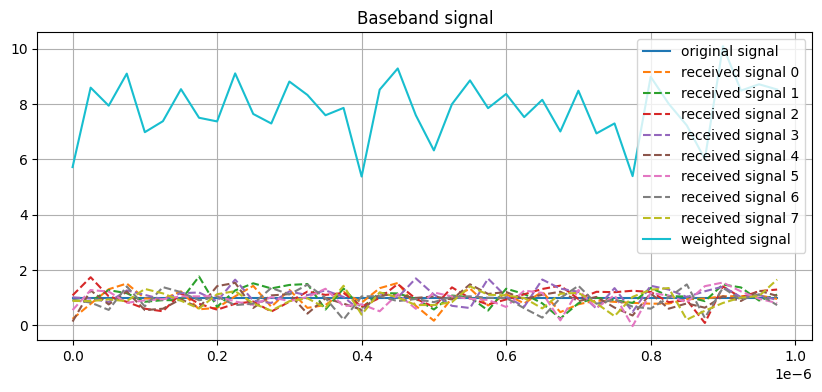

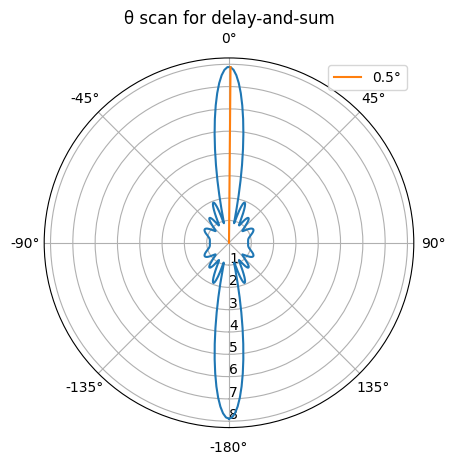

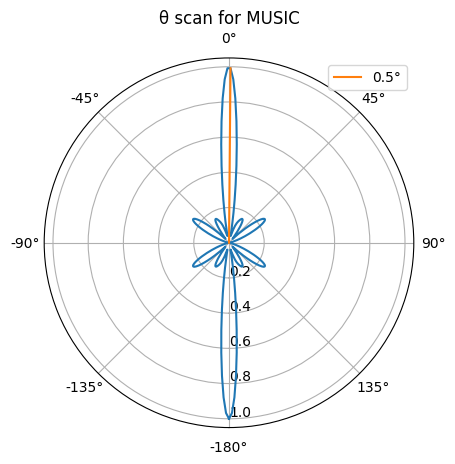

interactive(children=(IntSlider(value=10, description='SNR (dB)', max=40), IntSlider(value=0, description='DOA…

In [2]:
from ipywidgets import interact
import ipywidgets as widgets

import numpy as np
from signal_utils import add_noise
from signal_utils import power

import matplotlib.pyplot as plt


def plot_θ_scan(Θ, p, estimate_threshold, scan_source=""):
    _, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.plot(Θ, p)

    for i in range(1, len(p)-1):
        if p[i-1] < p[i] and p[i] > p[i+1] and p[i] > estimate_threshold:
            ax.plot([Θ[i], Θ[i]], [0, p[i]], label=f"{(Θ[i] / np.pi * 180).round(1)}°")

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(180)
    ax.set_thetamin(-180) # only show top half
    ax.set_thetamax(180)
    plt.title(f"θ scan for {scan_source}")
    plt.legend()
    plt.show()


def plot_signal(t, signal, steered_signal, weighted_signal):
    plt.figure(figsize=(10,4))
    plt.plot(t, signal.real, label="original signal")

    for i, x in enumerate(steered_signal):
        plt.plot(t, x.real, label=f"received signal {i}", linestyle="--")

    plt.plot(t, weighted_signal.real, label=f"weighted signal")
    plt.title("Baseband signal")
    plt.legend()
    plt.grid()
    plt.show()


@interact(
    snr_db=widgets.IntSlider(min=0, max=40, value=10, description="SNR (dB)"),
    doa=widgets.IntSlider(min=-90, max=90, description="DOA"),
    f=widgets.IntSlider(min=0, max=20, description="F (MHz)")
)
def run_beamforming_demo(snr_db, doa, f):
    sampling_rate=40e6
    pulse_duration = 1e-6 # 1 microsecond
    N = int(sampling_rate * pulse_duration)
    t = np.arange(N) / sampling_rate
    θ = np.radians(doa)
    signal = np.exp(2j * np.pi * f * 1e6 * t) # a rectangular pulse is just a wave with the frequency of 0, the generalized form is easier to change for debugging purposes
    snr = 10.0**(snr_db/10.0)
    steered_signal = np.array([
        add_noise(steered_signal, snr)
        for steered_signal in ula_instance.steer_signal(signal, θ)
    ])
    weighted_signal = ula_instance.delay_and_sum(steered_signal, θ)
    plot_signal(t, signal, steered_signal, weighted_signal)

    plot_θ_scan(*ula_instance.get_θ_scan(steered_signal), 0.9 * power(signal) * ula_instance.N, "delay-and-sum")
    plot_θ_scan(*ula_instance.music(steered_signal, 2), 0.5, "MUSIC")